<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter3_pytorch_computer_vision/optimizer_with_neural_network_in_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📁 **Thực hiện nạp thư viện cần thiết**

Nội dung của notebook này tập trung vào việc xây dựng một mô hình Nơ-ron để thực hiện phân loại ảnh trên bộ dữ liệu **Fashion-MNIST** qua đó cũng thực hiện việc so sánh 4 thuật toán tối ưu thông hàn hàm **Rosenbrock** biểu đồ **Training Loss**

Dữ liệu gồm: **70.000** ảnh grayscale 28 x 28 và **10** lớp dữ liệu:
- `T-shirt/top`
- `Trouser`
- `Pullover`
- `Dress`
- `Coat`
- `Sandal`
- `Shirt`
- `Sneaker`
- `Bag`
- `Ankle boot`

In [ ]:
import torch
import torch.nn as nn # Nạp PyTorch
from torch.utils.data import DataLoader # Dùng hàm DataLoader để nạp dữ liệu

import torchvision # Xây dựng hàm phân loại ảnh
import torchvision.transforms as transforms # Xây dưng các lớp tối ưu

import matplotlib.pyplot as plt # Minh họa plot
import numpy as np # Thư viện thao tác với dữ liệu
import time

torch.manual_seed(42) # Đặt random_seed

# 🤔 **So sánh các thuật toán tối ưu thông qua hàm Rosenbrock**

## **Hàm Rosenbrock**

**Khái niệm**:
Là một hàm toán học được sử dụng để:
- Kiểm tra các thuật toán tối ưu hóa
- Đánh giá các hàm optimizer trong các mô hình Học máy và Học Sâu
- Có thể trực quan hóa quá trình hội tụ

**Công thức**

Dạng phổ biến nhất trong 2 biến  
 $$f(x,y) = (a - x)^2 + b(y - x^2)^2$$

**Dặc điểm**

- *Có điểm rất hẹp:* Do các hàm tối ưu phẩi đi đúng hướng nhwuxng vấn ổn định, nếu không zig-zag liên tục
- *Gradient thay đổi mạnh:* Oử một số vùng gradient rấ lớn vùng khác lại rất nhỏ
- *Khó tối ưu:* Khó tìm cực tiểu, đặc biệt với hàm tối ưu đơn giản

**ý nghĩa khi sử dụng với Học sâu**

- So sánh Hàm tối ưu ()
- Quan sát
  - Tốc độ hội tụ
  - Dao động
  - Độ ổn định
  - Thay đổi learning_rate


In [ ]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2 # Theo dạng thông thường với a = 1, b = 100

**Nhận xét**

Chọn a = 1 và b = 100 do chúng tạo ra một bài toán tối ưu hòa đủ khó và có thể kiểm tra tốt các thuật toán tối ưu trong hàm Rosenbrock, **tham số a=1 được lựa chọn để cực tiểu toàn cục nằm tại điểm (1,1)**, giúp quá trình trực quan hóa trở nên dễ dàng hơn. **Tham số b=100 được sử dụng nhằm tạo ra một thung lũng cong và hẹp, làm cho bài toán tối ưu hóa trở nên khó khăn hơn đối với các thuật toán gradient-based.** Điều này giúp đánh giá rõ hơn khả năng hội tụ và độ ổn định của các optimizer như SGD, Momentum, RMSProp và Adam

## **Trực quan hóa các hàm hội tụ trong học sâu**

In [ ]:
# Xây dựng thuật toán tối ưu
def run_optimizer(make_optimizer):
    x = torch.tensor([-1.5], requires_grad=True) # Tạo tensors với tham số cập nhật Gradient tự động
    y = torch.tensor([1.5], requires_grad=True)

    optimizer = make_optimizer([x, y])
    trajectory = []
    for _ in range(500):
        optimizer.zero_grad() # Reset lại gradient
        loss = rosenbrock(x, y) # Tính hàm rosenbrock
        loss.backward() # Tính Gradient
        optimizer.step() # Áp dụng thuật toán tối ưu
        trajectory.append((x.item(), y.item())) # Thêm giá trị tối ưu
    return trajectory

In [ ]:
colors = {
    'SGD': '#ff6b6b',
    'Momentum': '#ffd93d',
    'RMSProp': '#4d96ff',
    'Adam': '#c77dff'
}

optimizers_surface = {
    'SGD':      lambda p: torch.optim.SGD(p, lr=0.001), # Tối ưu SGD
    'Momentum': lambda p: torch.optim.SGD(p, lr=0.001, momentum=0.9), # Tối ưu Momentum
    'RMSProp':  lambda p: torch.optim.RMSprop(p, lr=0.01), # Tối ưu RMSProp
    'Adam':     lambda p: torch.optim.Adam(p, lr=0.05) # Tối ưu Adam
}

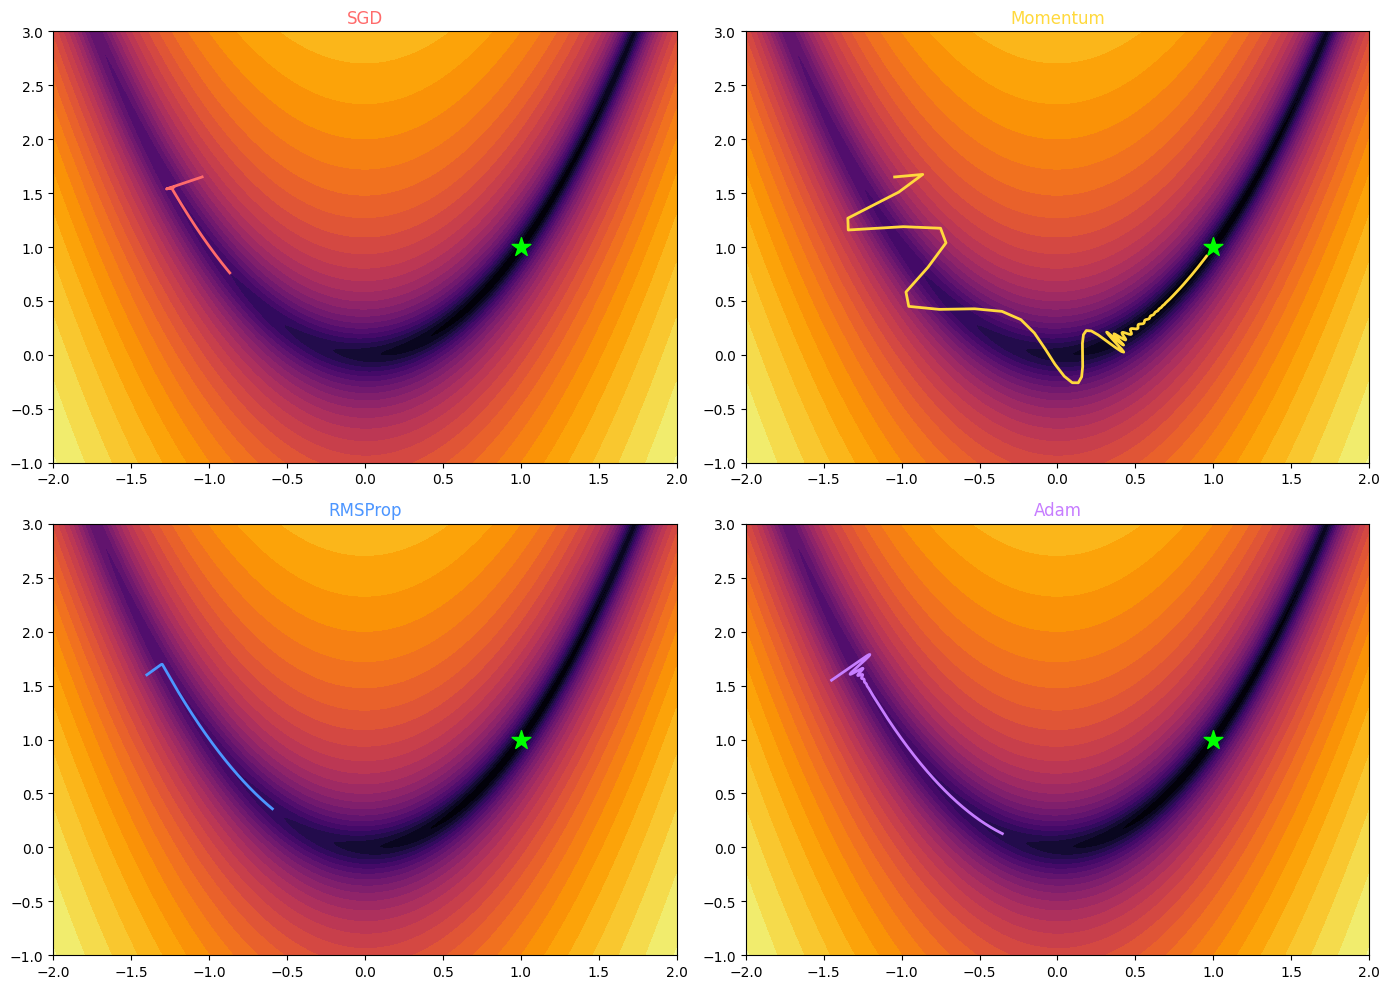

In [ ]:
# Tạo vùng dữ liệu
x_range = np.linspace(-2, 2, 300) # x thuộc [-2, 2]
y_range = np.linspace(-1, 3, 300) # y thuộc [-1, 3]

X, Y = np.meshgrid(x_range, y_range) # Tạo vector 2 chiều
Z = np.log1p(rosenbrock(X, Y)) # Tính giá trị hàm rosenbrock có nhiều giá trị rất lớn nên phải giảm chiều phù hợp cấu trúc valley

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, make_opt) in zip(axes.flat, optimizers_surface.items()):
    traj = run_optimizer(make_opt)
    xs, ys = zip(*traj)
    ax.contourf(X, Y, Z, levels=30, cmap='inferno')
    ax.plot(xs, ys, color=colors[name], linewidth=2)
    ax.scatter(1, 1, color='lime', marker='*', s=200)
    ax.set_title(name, color=colors[name])
plt.tight_layout()
plt.show()

**Nhận xét**

4 hình này minh họa quỹ đạo tối ưu hóa cảu 4 thuật toán phổ biến trên cùng một mất mát lấy hàm loss là (Rosenbrock):
- Nên: Giá trị loss với vùng loss thấp hơn là vùng tối
- Ngôi sao xanh: Điểm tối ưu
- Đường màu: Đường đi của tham số trong quá trình học

**1. SGD (Stochastic Gradient Descent):** Đường đi khá cứng di chuyển chậm theo thung lững, có nhiều bước zig-zag qua hai bên thành thung lũng, tiến gần tới tối ưu những không hiệu quả. SGD dùng gradient hiện tại:
$$
\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)
$$

Không nhớ những hướng trước đó nên:
- Đẽ dao động ở vùng con
- Đặc biệt khó trong các valley hẹp

*Ưu điểm:*
- Dễ dao động ở vùng cong
- Đặc biệt khó trong các valley hẹp

*Nhược điểm*
- Hội tụ chậm
- Nhạy với learning rate
- Dao động mạnh

**2. Momentum:** Đi nhanh hơn SGD, nhưng bị giao động rất mạnh có những đoạn lắc lưu gần điểm tối ưu trước khi ổn định. Hàm Momentum cải tiến hơn là thêm vào quán tinshm tăng tốc theo hướng đúng và giảm zig-zag:

$$
v_t = \beta v_{t-1} + \eta \nabla L(\theta_t)
$$

$$\theta_{t+1} = \theta_t - v_t$$

*Ưu điểm:*
- Nhanh hơn SGD
- Tốt cho làm landscape phức tạp

*Nhược điểm:*
- Có thể overshoot
- Cần tuning

**3. RMSProp:** Đường đi mượt hơn rõ rệt, ít dao động, tiến vào thung lũng khá ổn định. RMSProp tự điều chính tốc độ học theo từng chiều gradient chiều nào lớn thì tốc độ học chiều đó giảm

$$
s_t = \beta s_{t-1} + (1-\beta) g_t^2
$$

$$\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{s_t}+\epsilon} g_t$$

*Ưu điểm:*
- Hội tụ nhanh
- Ôn định

*Nhược điểm:*
- Không tổng quát tốt bằng SGD

**4. Adam:** Quỹ đạo mượt nhất, đi nhanh và ổn định, gần như không dao động lớn. Adam vừa nhó hướng đi vừa điều chỉnh được tốc độ học

$$
\hat{v}_t
=
\frac{v_t}{1-\beta_2^t}
$$

$$
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

*Ưu điểm:*
- Hội tụ nhanh
- Mạnh và ổn định

*Nhược điểm:*
- Không tổng quát tốt bằng SGD
- Có thể nghiệm tối ưu không bằng một số thuật toán tối ưu khác trong một số trường hợp

# ⚡**Xây dựng huấn luyện dữ liệu Fashion-MNIST**

## **Thực hiện nạp dữ liệu Fashion-MNIST**

In [ ]:
batch_size = 128 # Mỗi lần model cập nhật trọng số nó sẽ dùng 128 mẫu dữ liệu khác nhau

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train:", len(train_dataset)) # Tập train - 60000
print("Test :", len(test_dataset)) # Tập test - 10000

Train: 60000
Test : 10000


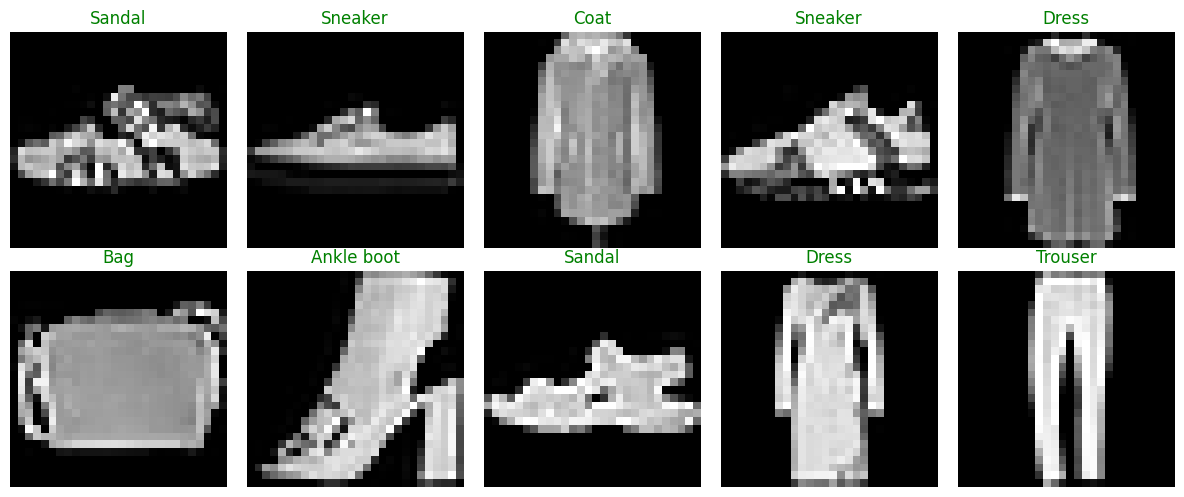

In [ ]:
# Định nghĩa lớp
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Duyệt qua các batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().cpu() # .cpu khi dữ liệu đang trên gpu

    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i]], color='green') # Nhãn đúng
    ax.axis('off')

plt.tight_layout()
plt.show()

## **Xây dựng Training Model**

### **Xây dựng Neural Network**

In [ ]:
input_dim = 28 * 28

class SimpleNet(nn.Module): # Định nghĩa model
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(), # Biến tensor từ 28 x 28 thành 784
            nn.Linear(input_dim, 256), # Lớp đầu tiên chuyển thành 256
            nn.ReLU(), # Chạy qua hàm kích hoạt giúp mạng học được các phi tuyến
            nn.Linear(256, 128), # Chuyền tiếp thành 128
            nn.ReLU(), # Chạy qua hàm kích hoạt tiếp
            nn.Linear(128, input_dim) # Cuối cùng chuyển về cùng chiều với input
        ) # Xây dựng Nơ ron với 4 lớp layer
    def forward(self, x): # Hàm forward
        return self.network(x)

### **Huấn luyện mô hình thông qua các hàm Optimizers**

In [ ]:
optimizers_surface_training = {
    'SGD':      lambda p: torch.optim.SGD(p, lr=0.01), # Tối ưu SGD
    'Momentum': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9), # Tối ưu Momentum
    'RMSProp':  lambda p: torch.optim.RMSprop(p, lr=0.001), # Tối ưu RMSProp
    'Adam':     lambda p: torch.optim.Adam(p, lr=0.001) # Tối ưu Adam
}

In [ ]:
epochs = 10
num_classes = 10

def train_model(optimizer_name, optimizer_dict, device='cuda' if torch.cuda.is_available() else 'cpu'):
    # Khởi tạo mô hình và đẩy lên thiết bị (GPU/CPU)
    model = SimpleNet().to(device)
    criterion = nn.CrossEntropyLoss()

    # Khởi tạo optimizer từ dictionary
    optimizer = optimizer_dict[optimizer_name](model.parameters())

    loss_history = []
    acc_history = []
    start = time.time()

    for epoch in range(epochs):
        model.train() # Đảm bảo model ở chế độ huấn luyện
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            # Đẩy dữ liệu lên thiết bị (GPU/CPU)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad() # Thực hiện làm mới gradient sau mỗi lần traing
            outputs = model(images) # Ghi lại dữ liệu đầu ra
            loss = criterion(outputs, labels) # Lưu lại kết quả
            loss.backward() # Tính gradient
            optimizer.step() # Cập nhật gradient rồi tối ưu

            total_loss += loss.item()

            # Tính toán độ chính xác
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(train_loader)
        avg_acc = 100 * correct / total

        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        print(f"{optimizer_name:9} | Epoch {epoch+1:2}/{epochs} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.2f}%")

    training_time = time.time() - start
    return model, loss_history, acc_history, training_time

In [ ]:
# Huấn luyện mô hình
results = {}

for name in optimizers_surface_training.keys():
    print("\n" + "=" * 50)
    model, loss, acc, t = train_model(name, optimizers_surface_training)
    results[name] = {
        'model': model,
        'loss': loss,
        'acc': acc,
        'time': t
    }


SGD       | Epoch  1/10 | Loss: 2.7126 | Acc: 33.65%
SGD       | Epoch  2/10 | Loss: 1.0185 | Acc: 62.54%
SGD       | Epoch  3/10 | Loss: 0.7979 | Acc: 70.26%
SGD       | Epoch  4/10 | Loss: 0.7026 | Acc: 74.28%
SGD       | Epoch  5/10 | Loss: 0.6460 | Acc: 76.76%
SGD       | Epoch  6/10 | Loss: 0.6032 | Acc: 78.77%
SGD       | Epoch  7/10 | Loss: 0.5724 | Acc: 80.00%
SGD       | Epoch  8/10 | Loss: 0.5466 | Acc: 80.97%
SGD       | Epoch  9/10 | Loss: 0.5245 | Acc: 81.67%
SGD       | Epoch 10/10 | Loss: 0.5105 | Acc: 82.09%

Momentum  | Epoch  1/10 | Loss: 1.0842 | Acc: 67.67%
Momentum  | Epoch  2/10 | Loss: 0.4990 | Acc: 82.46%
Momentum  | Epoch  3/10 | Loss: 0.4398 | Acc: 84.39%
Momentum  | Epoch  4/10 | Loss: 0.4084 | Acc: 85.52%
Momentum  | Epoch  5/10 | Loss: 0.3801 | Acc: 86.48%
Momentum  | Epoch  6/10 | Loss: 0.3557 | Acc: 87.22%
Momentum  | Epoch  7/10 | Loss: 0.3401 | Acc: 87.73%
Momentum  | Epoch  8/10 | Loss: 0.3283 | Acc: 88.20%
Momentum  | Epoch  9/10 | Loss: 0.3152 | Acc

**Nhận xét**

Qua kết quả huấn luyện, có thể thấy sự khác biệt rõ rệt giữa các optimizer về tốc độ hội tụ và độ chính xác đạt được.

**1. SGD**

SGD có tốc độ học chậm nhất trong bốn optimizer. Accuracy tăng dần từ 33.65% lên 82.09% sau 10 epoch, trong khi loss giảm từ 2.7126 xuống 0.5105. Điều này cho thấy SGD vẫn học được nhưng quá trình hội tụ diễn ra chậm do chỉ sử dụng gradient hiện tại để cập nhật trọng số, dễ xảy ra hiện tượng dao động trong không gian loss.

**2. Momentum**

Momentum cải thiện đáng kể so với SGD. Ngay từ epoch đầu tiên accuracy đã đạt 67.67% và tăng lên 89.06% sau 10 epoch. Loss giảm nhanh và ổn định hơn. Điều này chứng tỏ cơ chế tích lũy gradient giúp optimizer di chuyển nhanh hơn theo hướng tối ưu và giảm hiện tượng zig-zag trong quá trình học.

**3. RMSProp**

RMSProp cho kết quả tốt nhất trong thí nghiệm này với accuracy đạt 91.05% và loss thấp nhất là 0.2394. Optimizer này hội tụ nhanh ngay từ những epoch đầu và duy trì tốc độ cải thiện ổn định. Nguyên nhân là RMSProp có khả năng tự điều chỉnh learning rate cho từng tham số, giúp quá trình tối ưu hiệu quả hơn trên các bề mặt loss phức tạp.

**4. Adam**
Adam cũng cho kết quả rất tốt với accuracy cuối cùng đạt 90.51% và loss giảm còn 0.2552. Optimizer này học rất nhanh ở giai đoạn đầu nhờ kết hợp giữa Momentum và RMSProp. Tuy nhiên trong thí nghiệm này, accuracy cuối cùng của Adam vẫn thấp hơn RMSProp một chút.

Kết quả thực nghiệm cho thấy các optimizer adaptive như RMSProp và Adam hoạt động hiệu quả hơn SGD truyền thống trên mô hình neural network nhiều lớp.

# 📚 **Kết luận**

Optimizer  | Test Accuracy   | Time      
---------------------------------------------
SGD        |         81.90% |    67.86s
Momentum   |         87.15% |    67.83s
RMSProp    |         87.84% |    67.86s
Adam       |         88.05% |    69.24s


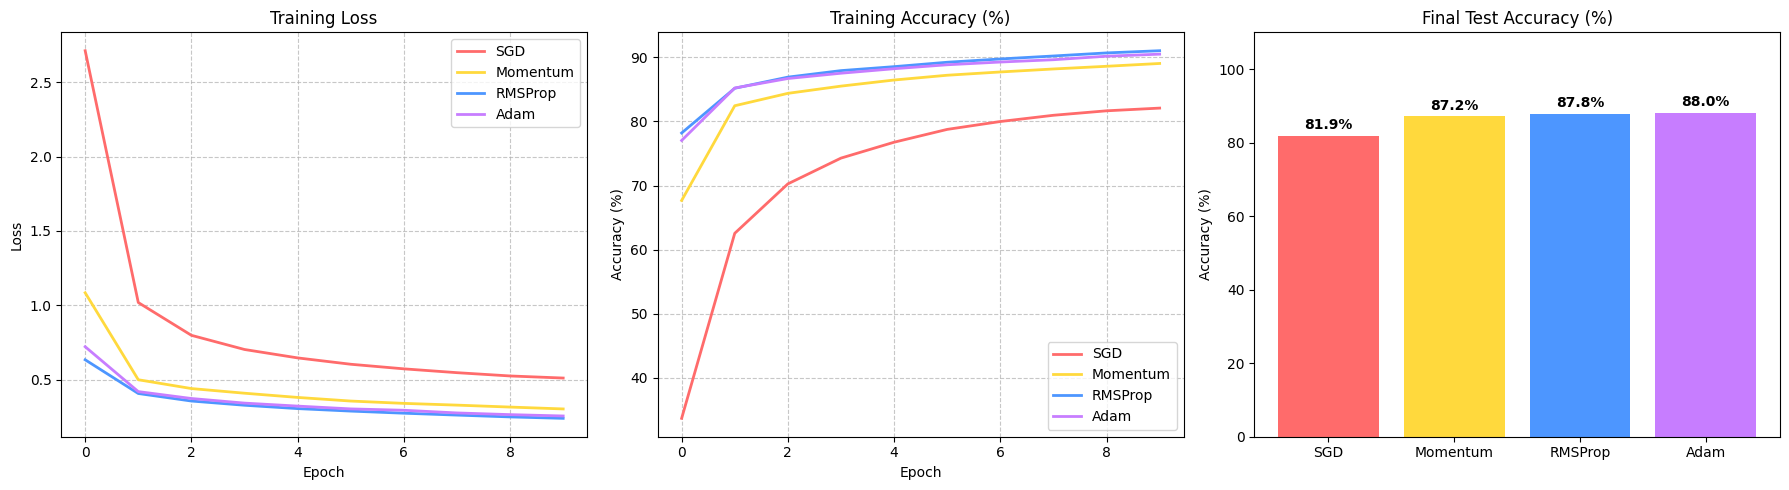

In [ ]:
# xác định thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- BIỂU ĐỒ LOSS ---
for name, result in results.items():
    axes[0].plot(result['loss'], label=name, color=colors.get(name, 'black'), linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- BIỂU ĐỒ TRAINING ACCURACY ---
for name, result in results.items():
    axes[1].plot(result['acc'], label=name, color=colors.get(name, 'black'), linewidth=2)
axes[1].set_title("Training Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- BIỂU ĐỒ TEST ACCURACY (BAR CHART) ---
test_accs = []
names = list(results.keys())

print(f"{'Optimizer':<10} | {'Test Accuracy':<15} | {'Time':<10}")
print("-" * 45)

for name in names:
    model = results[name]['model']
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    test_accs.append(acc)

    # In kết quả kiểm thử
    training_time = results[name].get('time', 0)
    print(f"{name:<10} | {acc:>13.2f}% | {training_time:>8.2f}s")

# Vẽ biểu đồ cột
# Lưu ý: Sử dụng colors.get(n) để tránh lỗi nếu tên không khớp
bar_colors = [colors.get(n, 'gray') for n in names]
bars = axes[2].bar(names, test_accs, color=bar_colors)

axes[2].set_title("Final Test Accuracy (%)")
axes[2].set_ylim(0, 110) # Tăng lên 110 để không bị đè chữ lên cạnh trên
axes[2].set_ylabel("Accuracy (%)")

# Thêm con số cụ thể trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%',
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét**

Biểu đồ thể hiện quá trình huấn luyện của bốn optimizer gồm SGD, Momentum, RMSProp và Adam thông qua ba tiêu chí: Training Loss, Training Accuracy và Final Test Accuracy.

**1. Training Loss**

Từ biểu đồ Training Loss có thể thấy:
- SGD có giá trị loss ban đầu rất cao và giảm chậm hơn các optimizer còn lại.
- Momentum giúp loss giảm nhanh hơn đáng kể nhờ cơ chế tích lũy gradient.
- RMSProp và Adam cho tốc độ giảm loss nhanh và ổn định nhất.
- RMSProp đạt loss thấp nhất ở cuối quá trình huấn luyện, cho thấy khả năng tối ưu hiệu quả trên bề mặt loss phi tuyến.

Điều này cho thấy các optimizer adaptive như RMSProp và Adam giúp mô hình hội tụ nhanh hơn so với SGD truyền thống.

---

**2. Training Accuracy**

Từ biểu đồ Training Accuracy:
- SGD có accuracy thấp nhất trong toàn bộ quá trình huấn luyện và tăng chậm qua từng epoch.
- Momentum cải thiện accuracy rõ rệt so với SGD.
- RMSProp và Adam đạt accuracy cao ngay từ các epoch đầu tiên.
- RMSProp đạt accuracy huấn luyện cao nhất vào cuối quá trình train.

Kết quả cho thấy:
- adaptive learning rate giúp mô hình học hiệu quả hơn,
- đồng thời giảm thời gian cần thiết để đạt độ chính xác cao.

---

**3. Final Test Accuracy**

Kết quả accuracy trên tập test:
- SGD: 81.9%
- Momentum: 87.2%
- RMSProp: 87.8%
- Adam: 88.0%

Adam đạt accuracy test cao nhất, trong khi RMSProp cho kết quả rất gần với Adam. SGD cho hiệu năng thấp nhất do tốc độ hội tụ chậm và khả năng tối ưu hạn chế hơn.

---

**Kết luận**

Qua thực nghiệm có thể thấy:
- SGD là optimizer đơn giản nhưng hội tụ chậm.
- Momentum cải thiện đáng kể tốc độ học và độ ổn định.
- RMSProp và Adam cho hiệu quả tốt nhất nhờ cơ chế adaptive learning rate.
- Adam và RMSProp phù hợp hơn cho các bài toán deep learning do khả năng hội tụ nhanh và đạt accuracy cao.
- SGD hội tụ chậm và cho kết quả thấp nhất.
- Momentum cải thiện đáng kể tốc độ học so với SGD.
- RMSProp đạt hiệu quả tốt nhất về cả loss và accuracy.
- Adam hội tụ nhanh và ổn định nhưng chưa vượt qua RMSProp trong bài toán này.